# 第 8 章 EDA 檢查表與練習

把第 8 章的探索式資料分析流程整理成可逐格執行的教學筆記。

學習目標：

- 建立訂單分析用的 facts table
- 使用數值欄位與類別欄位做 EDA 檢查
- 產生長條圖、箱型圖、趨勢圖、熱圖與分布圖
- 從 EDA 結果寫出簡短洞察與行動建議

## 1. 載入套件與資料

這一格會使用專案內的 `common.py` 輔助函式：

- `ensure_packages()`：檢查必要套件是否存在
- `load_data()`：讀取 `data/raw` 底下的 CSV
- `order_facts()`：把訂單明細彙整成訂單層級的營收資料
- `configure_plot_fonts()`：嘗試設定可顯示中文的字型

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from common import configure_plot_fonts, ensure_packages, load_data, order_facts

os.environ.setdefault("MPLCONFIGDIR", str((Path("data") / ".mplconfig").resolve()))

ensure_packages()
use_zh_labels = configure_plot_fonts()

data = load_data()
sorted(data.keys())

Using CJK font: Microsoft JhengHei


['ab_assignments',
 'customers',
 'events',
 'order_items',
 'orders',
 'products',
 'sessions']

## 2. 建立分析用 facts table

原始訂單資料通常分散在不同表格中。這裡先把訂單明細彙整成每筆訂單的 `line_revenue`，再串接顧客資料，讓後續可以依照城市、客群與取得通路分析。

In [2]:
facts = order_facts(data).merge(data["customers"], on="customer_id", how="left")

display(facts.head())
print(f"rows: {len(facts):,}")
print(f"date range: {facts['order_date'].min().date()} to {facts['order_date'].max().date()}")

,order_id,line_revenue,customer_id,order_date,status,payment_type,signup_date,acquisition_channel,city,segment
0,1,538.65,2323,2025-05-02,completed,wallet,2023-10-19,referral,Taipei,growth
1,2,4357.70,117,2024-07-14,completed,wallet,2024-09-19,organic,Kaohsiung,new
2,4,1193.40,1240,2024-07-08,completed,atm,2023-02-09,ads,Taichung,new
3,5,13175.50,714,2024-08-12,completed,atm,2023-01-24,partner,Hsinchu,growth
4,6,3657.50,2005,2025-01-14,completed,card,2023-07-20,ads,Taichung,new


rows: 20,413
date range: 2024-01-01 to 2025-12-31


## 3. 數值欄位檢查：訂單營收摘要

先看 `line_revenue` 的描述統計，確認平均數、中位數、最大值與分布範圍。這一步能快速判斷是否有極端值或右偏分布。

In [3]:
revenue_summary = facts[["line_revenue"]].describe().round(2)
display(revenue_summary)

,line_revenue
count,20413.00
mean,4985.64
std,3631.51
min,100.80
25%,2262.00
50%,4164.30
75%,6829.50
max,29288.20


## 4. 類別欄位檢查：各通路平均訂單金額

把數值欄位與類別欄位交叉檢查，是 EDA 很常見的第一輪問題：不同取得通路帶來的訂單價值是否不同？

In [4]:
channel_aov = (
    facts.groupby("acquisition_channel")["line_revenue"]
    .mean()
    .sort_values(ascending=False)#大到小排序
    .round(2)
)

display(channel_aov.to_frame("avg_order_value"))

,avg_order_value
acquisition_channel,
social,5019.50
organic,5015.92
partner,4994.68
referral,4992.62
ads,4910.90


## 5. 範例一：付款方式訂單數長條圖

這張圖來自 `lesson08.py` 的第一個範例。長條圖適合比較類別資料的數量，例如不同付款方式的訂單數。

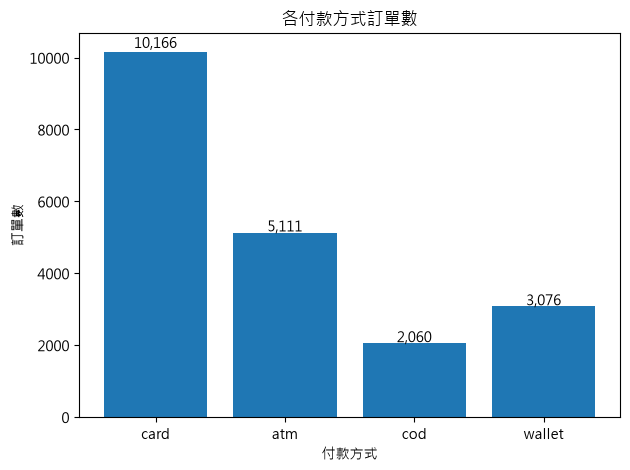

In [6]:
out_dir = Path("data") / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

payment_counts = (
    facts.groupby("payment_type")["order_id"]
    .count()
    .reindex(["card", "atm", "cod", "wallet"])
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots()#figsize=(8, 5)
ax.bar(payment_counts.index.tolist(), payment_counts.values.tolist())
ax.set_title("各付款方式訂單數")
ax.set_xlabel("付款方式")
ax.set_ylabel("訂單數")

for i, v in enumerate(payment_counts.values.tolist()):
    ax.text(i, v + max(1, int(v * 0.01)), f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig(out_dir / "payment_orders.png", dpi=150)
plt.show()

## 6. 範例二：客群營收箱型圖

箱型圖可以同時觀察中位數、四分位距與離群值。這裡比較 `new`、`growth`、`vip` 三個客群的訂單營收分布。

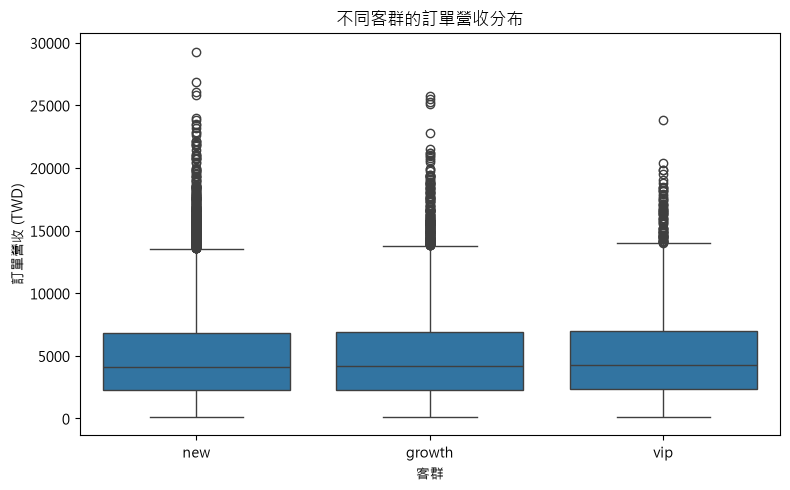

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=facts,
    x="segment",
    y="line_revenue",
    ax=ax,
    order=["new", "growth", "vip"],
)
ax.set_title("不同客群的訂單營收分布")
ax.set_xlabel("客群")
ax.set_ylabel("訂單營收 (TWD)")
plt.tight_layout()
plt.savefig(out_dir / "segment_boxplot.png", dpi=150)
plt.show()

## 7. 範例三：每日營收與 7 日移動平均

折線圖(直線圖)適合看時間序列。原始每日營收可能波動較大，因此加上 7 日移動平均線，幫助觀察較平滑的趨勢。

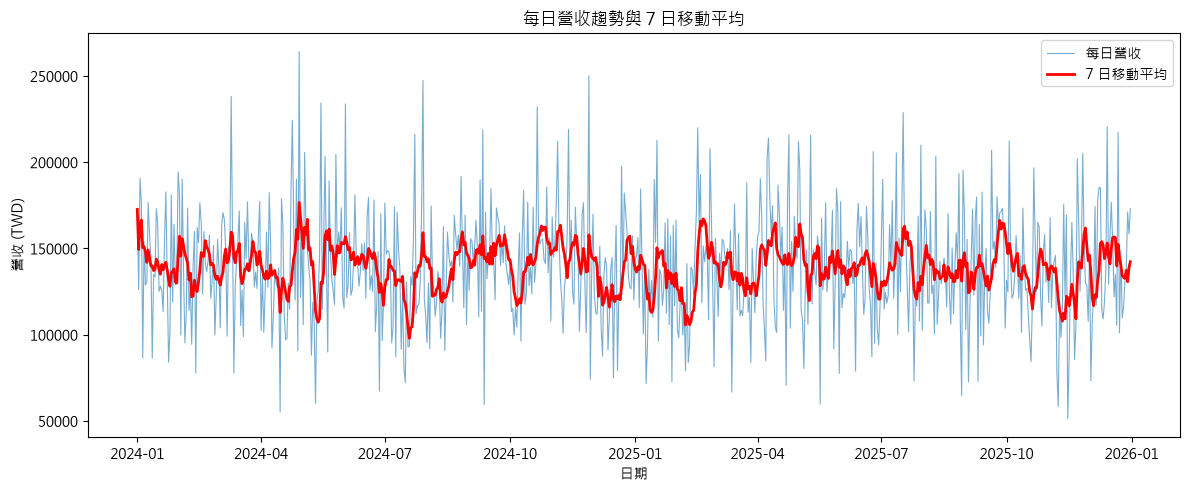

In [8]:
daily = facts.groupby(facts["order_date"].dt.date, as_index=False)["line_revenue"].sum()
daily.columns = ["date", "revenue"]
daily["ma7"] = daily["revenue"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["revenue"], linewidth=0.8, alpha=0.6, label="每日營收")
ax.plot(daily["date"], daily["ma7"], linewidth=2, color="red", label="7 日移動平均")
ax.set_title("每日營收趨勢與 7 日移動平均")
ax.set_xlabel("日期")
ax.set_ylabel("營收 (TWD)")
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "daily_revenue_trend.png", dpi=150)
plt.show()

## 8. 範例四：通路 x 客群平均營收熱(力)圖

熱(力)圖適合看兩個類別欄位交叉後的數值差異。顏色越深，代表該通路與客群組合的平均訂單營收越高。

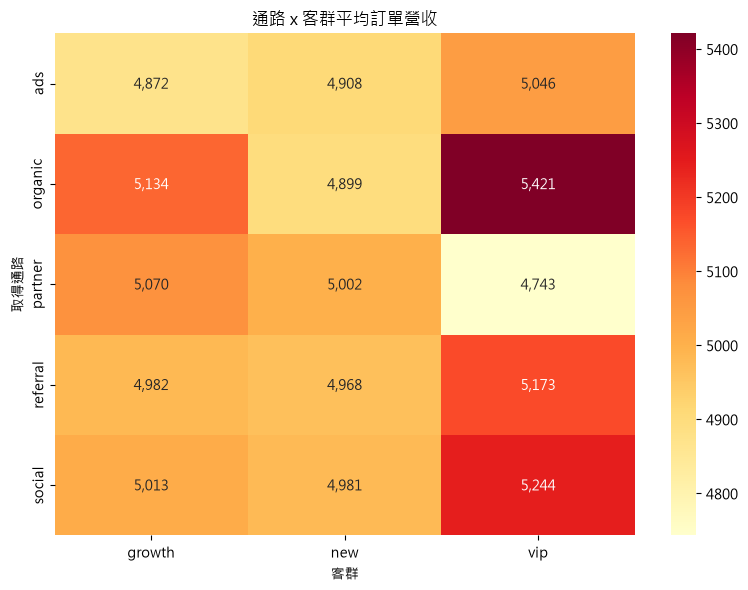

In [9]:
cross = facts.pivot_table(
    values="line_revenue",
    index="acquisition_channel",
    columns="segment",
    aggfunc="mean",
).round(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cross, annot=True, fmt=",.0f", cmap="YlOrRd", ax=ax)
ax.set_title("通路 x 客群平均訂單營收")
ax.set_xlabel("客群")
ax.set_ylabel("取得通路")
plt.tight_layout()
plt.savefig(out_dir / "channel_segment_heatmap.png", dpi=150)
plt.show()

## 9. 練習任務一：城市層級統計

這段融合 `practice_ch08.py` 的第一個任務：依城市計算訂單數、平均訂單金額與總營收，並用水平長條圖比較各城市 AOV。

,order_count,avg_order_value,total_revenue
city,,,
Hsinchu,3571,5112.72,18257524.65
Kaohsiung,3259,5071.97,16529550.15
Taoyuan,3117,4983.62,15533934.55
Tainan,3745,4940.57,18502432.75
Taichung,3358,4914.58,16503144.75
Taipei,3363,4890.04,16445212.90


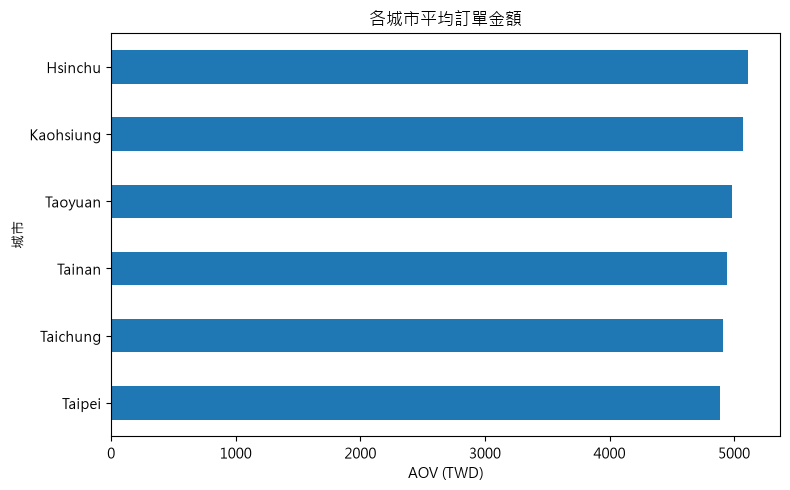

In [10]:
city_stats = (
    facts.groupby("city")["line_revenue"]
    .agg(
        order_count="count",
        avg_order_value="mean",
        total_revenue="sum",
    )
    .round(2)
    .sort_values("avg_order_value", ascending=False)
)

display(city_stats)

fig, ax = plt.subplots(figsize=(8, 5))
city_stats["avg_order_value"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("各城市平均訂單金額")
ax.set_xlabel("AOV (TWD)")
ax.set_ylabel("城市")
plt.tight_layout()
plt.savefig(out_dir / "practice_ch08_city_aov.png", dpi=150)
plt.show()

## 10. 練習任務二：營收分布診斷

除了 `describe()`，偏態係數與峰度也能幫助判斷分布形狀。若平均數明顯高於中位數，通常代表右側有高金額訂單拉高平均。

,line_revenue
count,20413.00
mean,4985.64
std,3631.51
min,100.80
25%,2262.00
50%,4164.30
75%,6829.50
max,29288.20


skewness: 1.30
kurtosis: 2.16


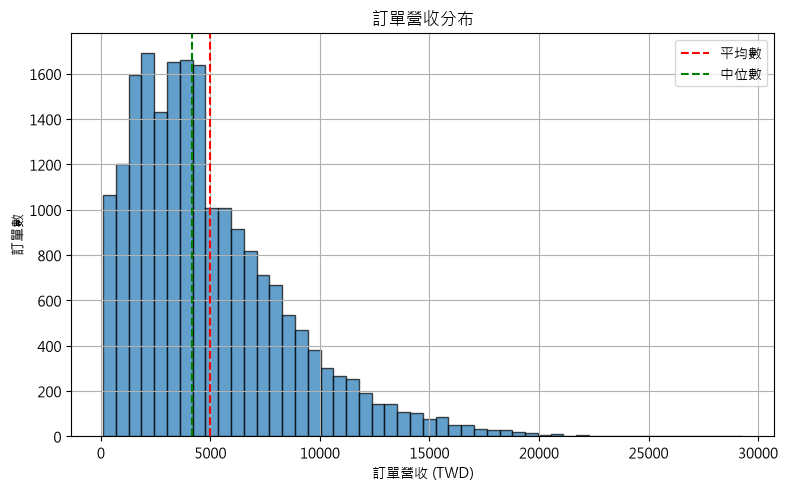

In [11]:
display(facts["line_revenue"].describe().round(2).to_frame("line_revenue"))
print(f"skewness: {facts['line_revenue'].skew():.2f}")
print(f"kurtosis: {facts['line_revenue'].kurtosis():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
facts["line_revenue"].hist(bins=50, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(facts["line_revenue"].mean(), color="red", linestyle="--", label="平均數")
ax.axvline(facts["line_revenue"].median(), color="green", linestyle="--", label="中位數")
ax.legend()
ax.set_title("訂單營收分布")
ax.set_xlabel("訂單營收 (TWD)")
ax.set_ylabel("訂單數")
plt.tight_layout()
plt.savefig(out_dir / "practice_ch08_revenue_distribution.png", dpi=150)
plt.show()

## 11. 練習任務三：洞察與建議

EDA 不只產生圖表，也要能轉成一句清楚的發現與一個可行的下一步。下面用通路 AOV 的最高與最低值，產生一段範例洞察。

In [12]:
top_channel = channel_aov.index[0]
low_channel = channel_aov.index[-1]
top_val = float(channel_aov.iloc[0])
low_val = float(channel_aov.iloc[-1])
gap = top_val - low_val
gap_pct = (gap / low_val) if low_val > 0 else 0.0

print(
    f"洞察：{top_channel} 通路 AOV 為 {top_val:.0f} TWD，"
    f"比 {low_channel} 的 {low_val:.0f} TWD 高 {gap:.0f} TWD "
    f"({gap_pct * 100:.1f}%)."
)
print(
    f"建議：檢查 {low_channel} 的受眾、素材與落地頁，"
    f"並在 {top_channel} 加碼小型實驗，確認高 AOV 是否能穩定擴大。"
)

洞察：social 通路 AOV 為 5020 TWD，比 ads 的 4911 TWD 高 109 TWD (2.2%).
建議：檢查 ads 的受眾、素材與落地頁，並在 social 加碼小型實驗，確認高 AOV 是否能穩定擴大。


## 12. 小練習

請嘗試修改下面的程式，找出「不同付款方式」在各客群中的平均訂單營收。

提示：可以使用 `pivot_table()`，把 `payment_type` 放在列，`segment` 放在欄，數值使用 `line_revenue` 的平均。

In [ ]:
# 練習：完成 payment_type x segment 的平均營收表
practice_cross = facts.pivot_table(
    values="line_revenue",
    index="payment_type",
    columns="segment",
    aggfunc="mean",
).round(0)

display(practice_cross)

## 常見錯誤與延伸方向

常見錯誤：直接拿未過濾的訂單計算營收，可能把取消或未完成訂單也算進去。這份 notebook 使用 `order_facts()`，其中已保留 `status == 'completed'` 的訂單。

延伸方向：可以把時間維度加入通路分析，例如比較各通路每週 AOV 的變化，觀察某個通路是否只是在特定活動期間表現較好。

## 產出圖檔

執行完 notebook 後，圖檔會儲存在 `data/outputs`：

- `payment_orders.png`
- `segment_boxplot.png`
- `daily_revenue_trend.png`
- `channel_segment_heatmap.png`
- `practice_ch08_city_aov.png`
- `practice_ch08_revenue_distribution.png`